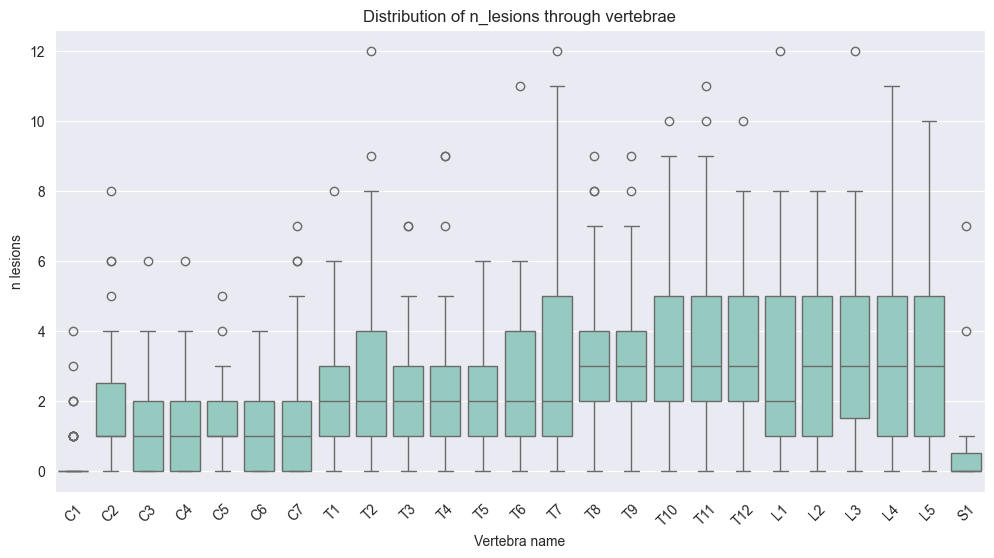

In [2]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

main_folder = r"E:\DATA_Myelomy"
all_data = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)
    csv_path = os.path.join(folder_path, "BMD_radiomics_vertebrae_features.csv")

    if os.path.isfile(csv_path):
        df = pd.read_csv(csv_path)
        df = df[['vertebra_name', 'n_lesions']]
        all_data.append(df)

full_df = pd.concat(all_data, ignore_index=True)

plt.figure(figsize=(12,6))
sns.set_style("darkgrid")
sns.boxplot(x='vertebra_name', y='n_lesions', data=full_df)
plt.title('Distribution of n_lesions through vertebrae')
plt.xlabel('Vertebra name')
plt.ylabel('n lesions')
plt.xticks(rotation=45)
plt.show()

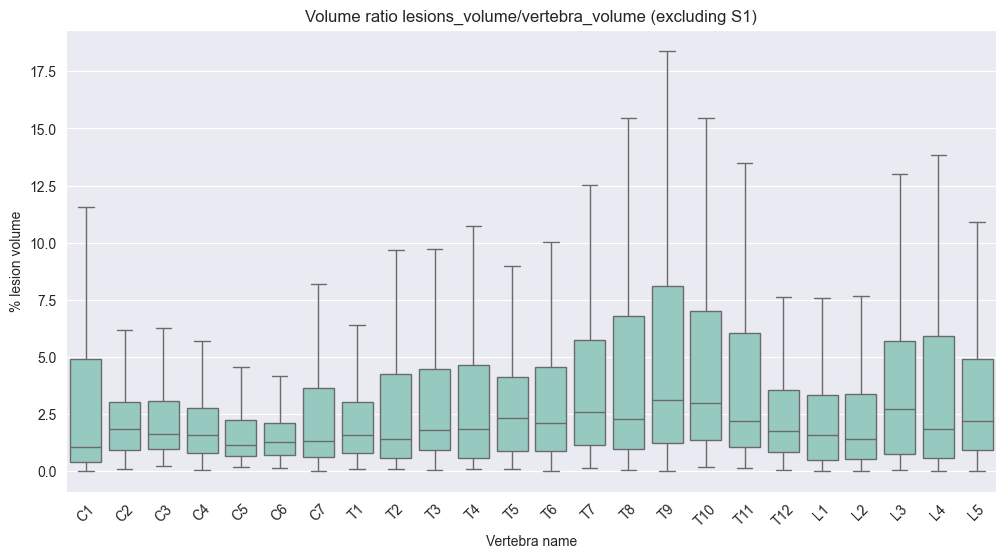

In [3]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

main_folder = r"E:\DATA_Myelomy"

vertebra_data = []
lesion_data = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)

    vertebra_csv = os.path.join(folder_path, "BMD_radiomics_vertebrae_features.csv")
    lesion_csv = os.path.join(folder_path, "BMD_radiomics_lesions_features.csv")

    if os.path.isfile(vertebra_csv):
        df_v = pd.read_csv(vertebra_csv)
        df_v = df_v[['vertebra_name', 'original_shape_VoxelVolume']]
        vertebra_data.append(df_v)

    if os.path.isfile(lesion_csv):
        df_l = pd.read_csv(lesion_csv)
        df_l = df_l[['vertebra_name', 'original_shape_VoxelVolume']]
        lesion_data.append(df_l)

# combine all vertebra and lesion data
df_vertebra = pd.concat(vertebra_data, ignore_index=True)
df_lesion = pd.concat(lesion_data, ignore_index=True)

df_lesion["lesions_volume"] = df_lesion["original_shape_VoxelVolume"]
df_vertebra["vertebra_volume"] = df_vertebra["original_shape_VoxelVolume"]

# merge with vertebra volume, fill missing lesion sums with 0
df = pd.merge(df_vertebra, df_lesion, on='vertebra_name', how='left')

# calculate lesion percentage
df['lesion_percent'] = df['lesions_volume'] / df['vertebra_volume'] * 100

# remove S1 vertebra
df = df[df['vertebra_name'] != 'S1']

# visualization
plt.figure(figsize=(12,6))
sns.set_style("darkgrid")
sns.boxplot(x='vertebra_name', y='lesion_percent', data=df, showfliers=False)
plt.title('Volume ratio lesions_volume/vertebra_volume (excluding S1)')
plt.xlabel('Vertebra name')
plt.ylabel('% lesion volume')
plt.xticks(rotation=45)
plt.show()

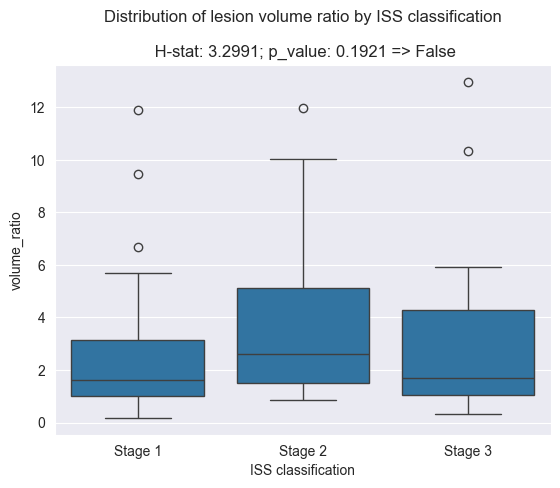

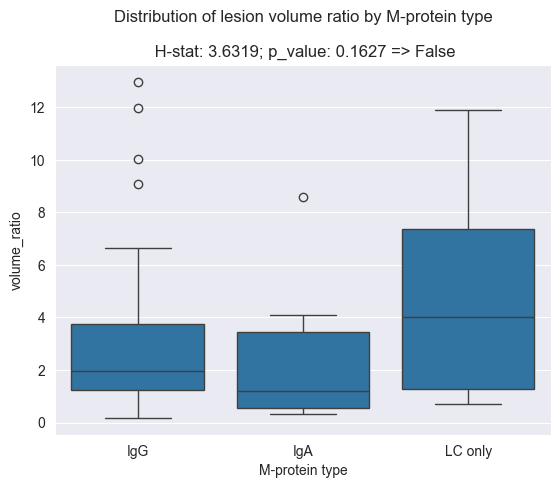

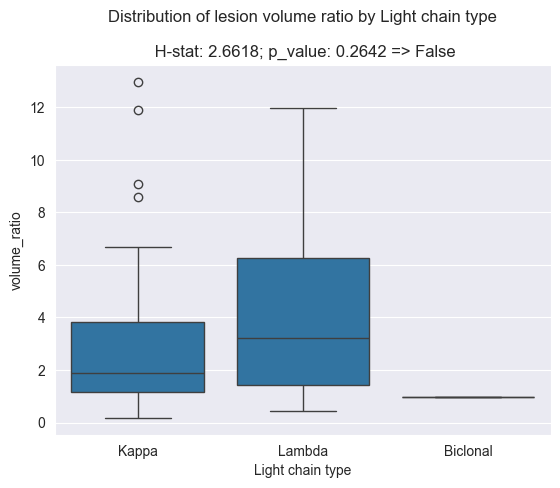

In [16]:
# RELATION BETWEEN LESIONS VOLUME RATIO AND CLINICAL VARIABLES -> KRUSKAL-WALLIS TEST
import pandas as pd
import seaborn as sns
from scipy.stats import kruskal, spearmanr
import matplotlib.pyplot as plt


df_lesions = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])
df_vertebrae = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_vertebrae_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])

df_lesions = df_lesions.rename(columns={'original_shape_VoxelVolume': 'lesions_volume'})
df_vertebrae = df_vertebrae.rename(columns={'original_shape_VoxelVolume': 'vertebrae_volume'})

data = pd.merge(df_lesions, df_vertebrae[['patient', 'vertebrae_volume']], left_on='patient', right_on='patient')
categoric_features_clinical = ["ISS classification", "M-protein type", "Light chain type"]

pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
df_final = pd.merge(data, clinical_df, left_on='patient', right_on='Patient ID')

df_final['volume_ratio'] = df_final['lesions_volume'] / df_final['vertebrae_volume'] * 100

for cat_col in categoric_features_clinical:
    groups = [group['volume_ratio'].dropna().values for name, group in df_final.groupby(cat_col)]

    if len(groups) > 1:
        stat, p_value = kruskal(*groups)


        sns.boxplot(data=df_final, x=cat_col, y="volume_ratio")
        plt.title(f'Distribution of lesion volume ratio by {cat_col}\n\n H-stat: {stat:.4f}; p_value: {p_value:.4f} => {p_value < 0.05}')
        plt.show()
        print()

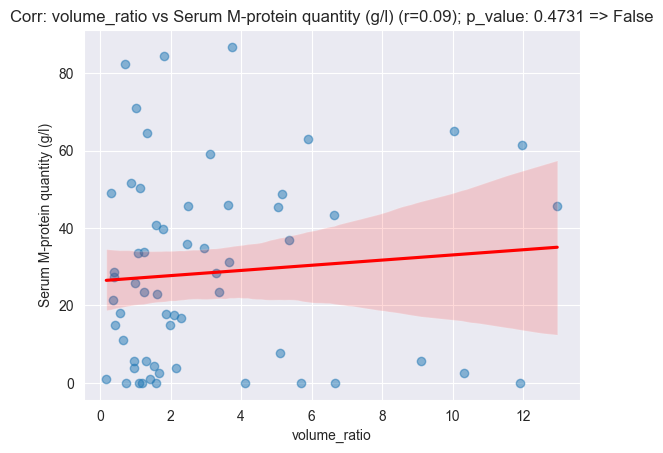

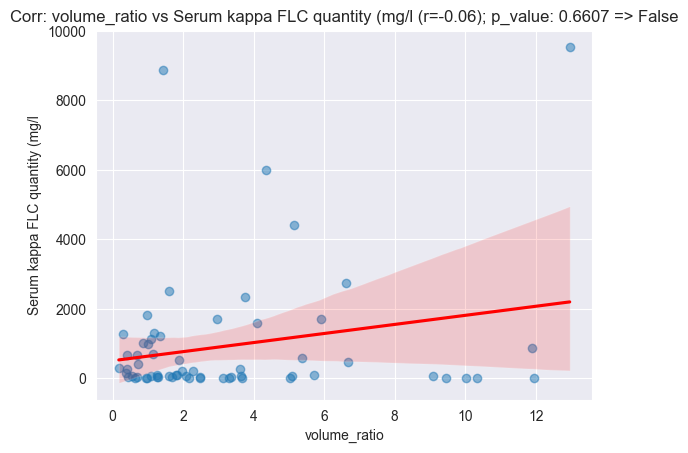

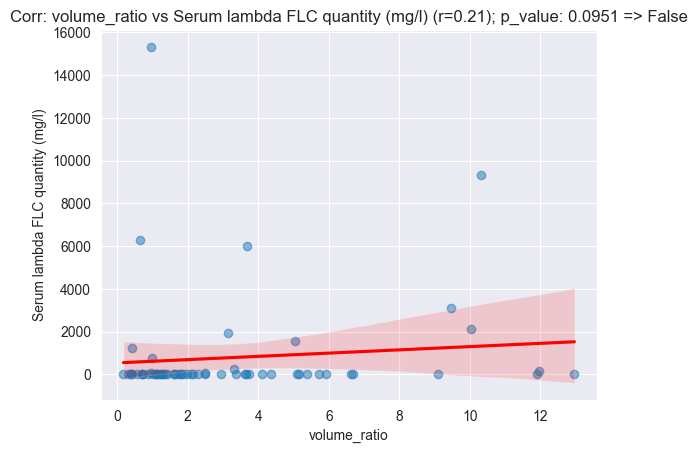

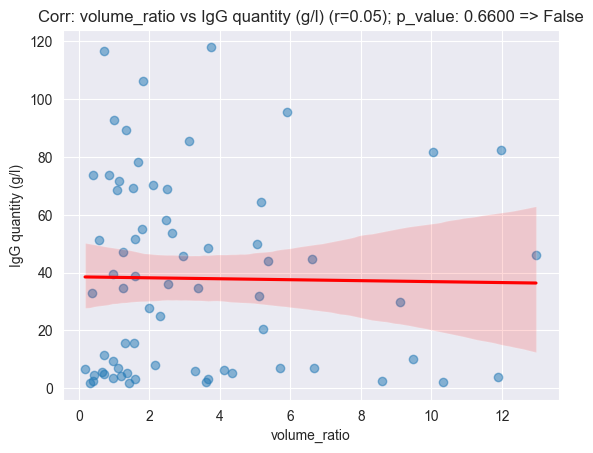

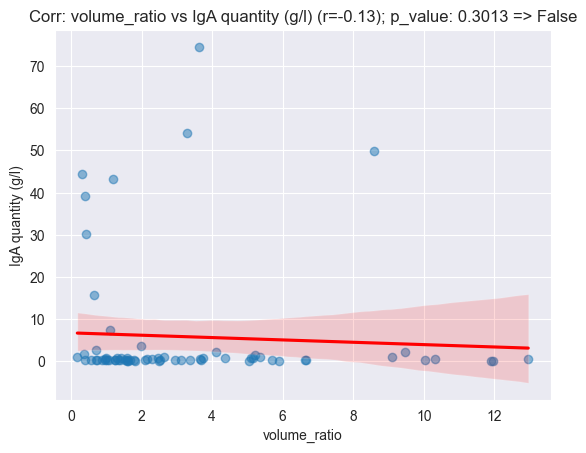

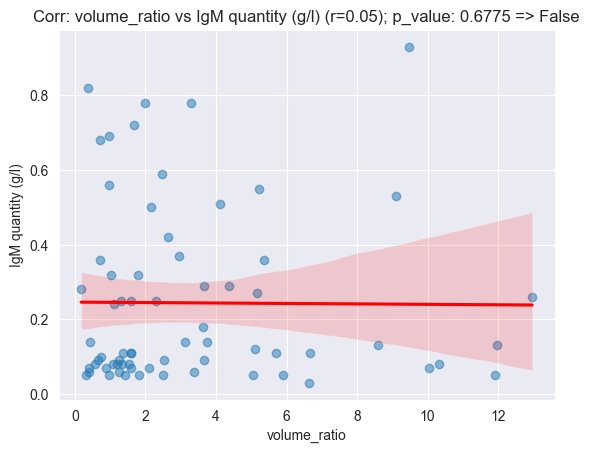

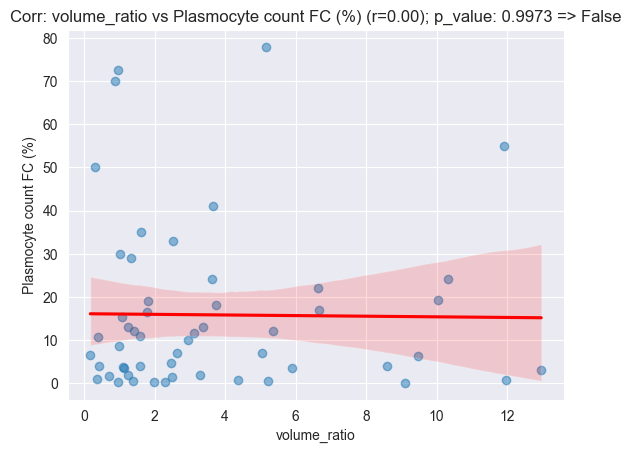

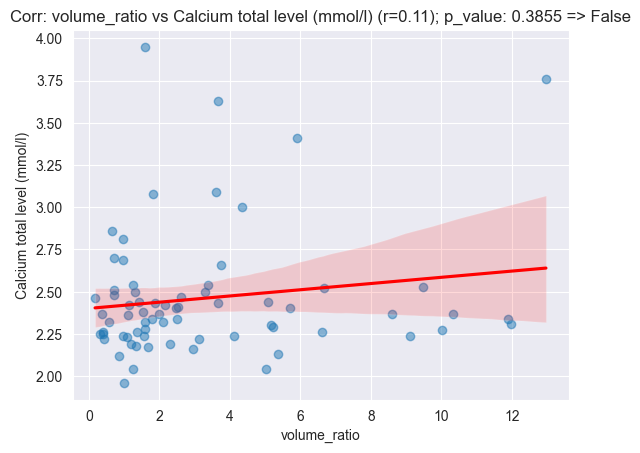

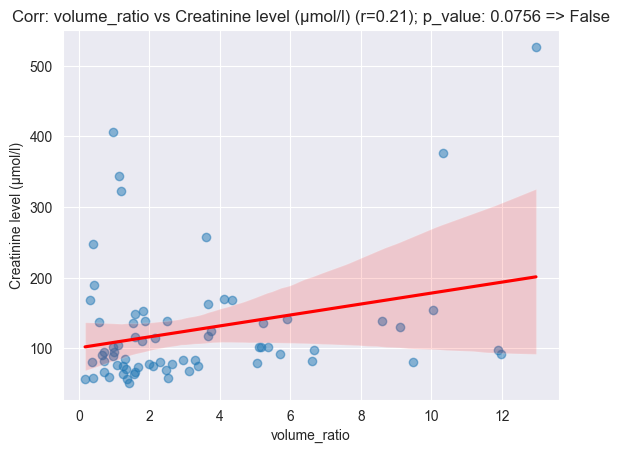

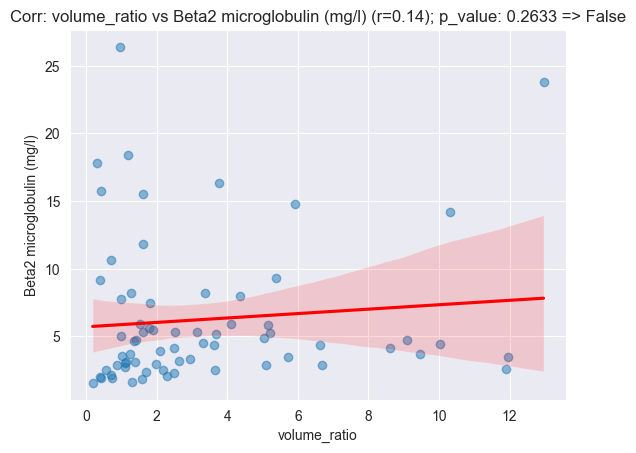

In [17]:
# RELATION BETWEEN LESIONS VOLUME RATIO AND CLINICAL VARIABLES -> SPEARMAN TEST
df_lesions = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])
df_vertebrae = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_vertebrae_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])

df_lesions = df_lesions.rename(columns={'original_shape_VoxelVolume': 'lesions_volume'})
df_vertebrae = df_vertebrae.rename(columns={'original_shape_VoxelVolume': 'vertebrae_volume'})

data = pd.merge(df_lesions, df_vertebrae[['patient', 'vertebrae_volume']], left_on='patient', right_on='patient')

pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
df_final = pd.merge(data, clinical_df, left_on='patient', right_on='Patient ID')

numeric_features_clinical = clinical_df.select_dtypes(include=['number']).columns

df_final['volume_ratio'] = df_final['lesions_volume'] / df_final['vertebrae_volume'] * 100

for num_col in numeric_features_clinical:
    corr, p_value = spearmanr(df_final['volume_ratio'], df_final[num_col], nan_policy='omit')


    sns.regplot(data=df_final, x='volume_ratio', y=num_col,
                    scatter_kws={'alpha':0.5}, line_kws={'color': 'red'})

    plt.title(f"Corr: {'volume_ratio'} vs {num_col} (r={corr:.2f}); p_value: {p_value:.4f} => {p_value < 0.05}")
    plt.xlabel('volume_ratio')
    plt.ylabel(num_col)
    plt.show()
    print()

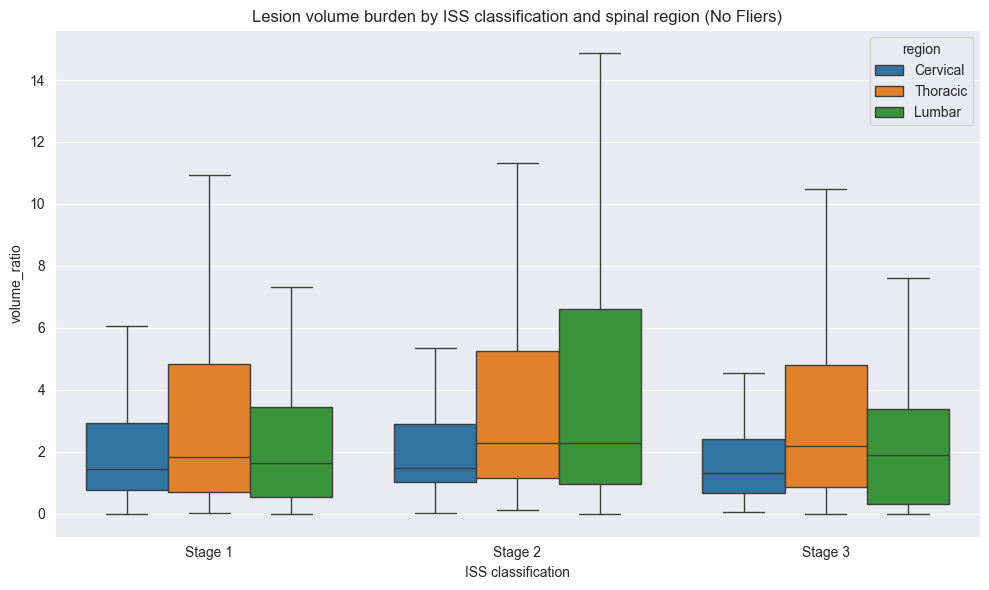


STATISTICAL ANALYSIS: Kruskal-Wallis Test

Region: Cervical
p-value: 0.4301
Significant (p < 0.05): NO

Region: Thoracic
p-value: 0.0807
Significant (p < 0.05): NO

Region: Lumbar
p-value: 0.0022
Significant (p < 0.05): YES


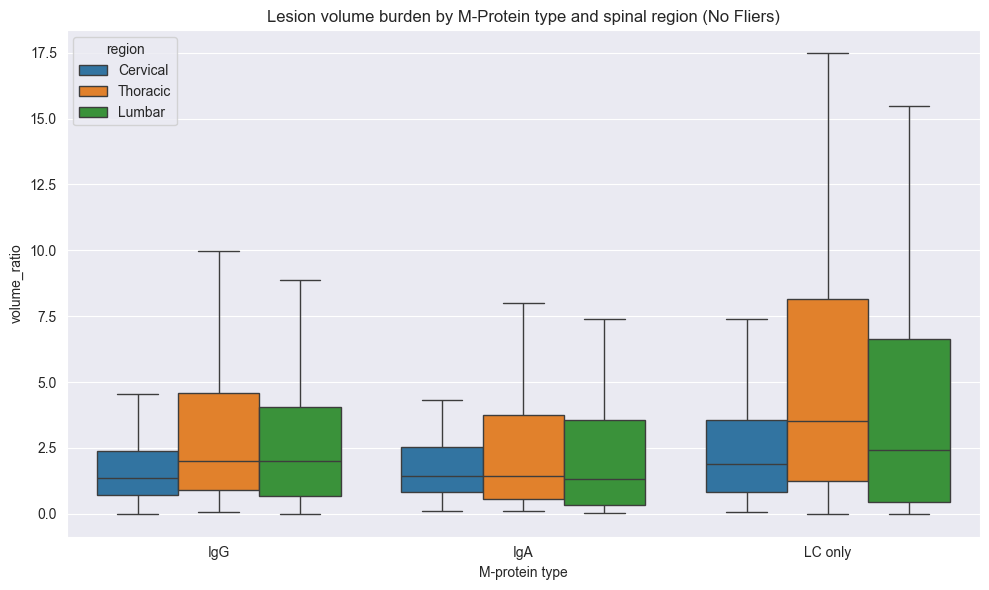


STATISTICAL ANALYSIS: Kruskal-Wallis Test

Region: Cervical
p-value: 0.0842
Significant (p < 0.05): NO

Region: Thoracic
p-value: 0.0000
Significant (p < 0.05): YES

Region: Lumbar
p-value: 0.2941
Significant (p < 0.05): NO


In [18]:
# RELATION BETWEEN CATEGORICAL VARIABLES SEPARATELY IN C/T/L VERTEBRAE -> KRUSKAL-WALLIS TEST
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal

# --- 1. Load and Clean Data ---
main_folder = r"E:\DATA_Myelomy"
lesion_data = []
vertebra_data = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)
    lesion_csv = os.path.join(folder_path, "monoe_40kev_radiomics_lesions_features.csv")
    vertebra_csv = os.path.join(folder_path, "monoe_40kev_radiomics_vertebrae_features.csv")

    if os.path.isfile(lesion_csv):
        df_l = (pd.read_csv(lesion_csv).filter(items=["vertebra_name", "original_shape_VoxelVolume"]))
        df_l["patient"] = folder_name
        lesion_data.append(df_l)

    if os.path.isfile(vertebra_csv):
        df_v = (pd.read_csv(vertebra_csv).filter(items=["vertebra_name", "original_shape_VoxelVolume"]))
        df_v["patient"] = folder_name
        vertebra_data.append(df_v)

# Combine and merge
df_lesions = pd.concat(lesion_data, ignore_index=True).rename(columns={"original_shape_VoxelVolume": "lesions_volume"})
df_vertebra = pd.concat(vertebra_data, ignore_index=True).rename(columns={"original_shape_VoxelVolume": "vertebra_volume"})
df = pd.merge(df_lesions, df_vertebra, on=["patient", "vertebra_name"])
df = df[df["vertebra_name"] != "S1"]

# Define regions
cervical = [f'C{i}' for i in range(1,8)]
thoracic = [f'T{i}' for i in range(1,13)]
lumbar = [f'L{i}' for i in range(1,6)]

def map_region(vertebra):
    if vertebra in cervical: return 'Cervical'
    elif vertebra in thoracic: return 'Thoracic'
    else: return 'Lumbar'

df['region'] = df['vertebra_name'].apply(map_region)

# Merge clinical data
pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
df_final = pd.merge(df, clinical_df[['Patient ID', 'ISS classification']], left_on='patient', right_on='Patient ID')
df_final['volume_ratio'] = df_final['lesions_volume'] / df_final['vertebra_volume'] * 100

# Plot 2: No Fliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final, x="ISS classification", y="volume_ratio", hue="region", hue_order=["Cervical", "Thoracic", "Lumbar"], showfliers=False)
plt.title("Lesion volume burden by ISS classification and spinal region (No Fliers)")
plt.tight_layout()
plt.show()

# --- 3. Statistical Analysis: Kruskal-Wallis ---
print("\n" + "="*50)
print("STATISTICAL ANALYSIS: Kruskal-Wallis Test")
print("="*50)

regions = ["Cervical", "Thoracic", "Lumbar"]

for region in regions:
    subset = df_final[df_final['region'] == region].dropna()
    groups = [group['volume_ratio'].values for name, group in subset.groupby('ISS classification')]

    if len(groups) > 1:
        stat, p_value = kruskal(*groups)
        print(f"\nRegion: {region}")
        print(f"p-value: {p_value:.4f}")
        print(f"Significant (p < 0.05): {'YES' if p_value < 0.05 else 'NO'}")
    else:
        print(f"\nRegion: {region}: Insufficient data to compare ISS groups.")





# M-PROTEIN TYPE
# Merge clinical data
pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
df_final = pd.merge(df, clinical_df[['Patient ID', 'M-protein type']], left_on='patient', right_on='Patient ID')
df_final['volume_ratio'] = df_final['lesions_volume'] / df_final['vertebra_volume'] * 100

# Plot 2: No Fliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final, x="M-protein type", y="volume_ratio", hue="region", hue_order=["Cervical", "Thoracic", "Lumbar"], showfliers=False)
plt.title("Lesion volume burden by M-Protein type and spinal region (No Fliers)")
plt.tight_layout()
plt.show()

# --- 3. Statistical Analysis: Kruskal-Wallis ---
print("\n" + "="*50)
print("STATISTICAL ANALYSIS: Kruskal-Wallis Test")
print("="*50)

regions = ["Cervical", "Thoracic", "Lumbar"]

for region in regions:
    subset = df_final[df_final['region'] == region].dropna()
    groups = [group['volume_ratio'].values for name, group in subset.groupby('M-protein type')]

    if len(groups) > 1:
        stat, p_value = kruskal(*groups)
        print(f"\nRegion: {region}")
        print(f"p-value: {p_value:.4f}")
        print(f"Significant (p < 0.05): {'YES' if p_value < 0.05 else 'NO'}")
    else:
        print(f"\nRegion: {region}: Insufficient data to compare M-Protein type.")

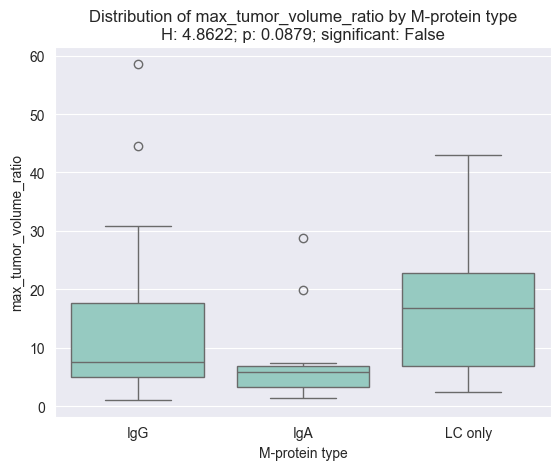

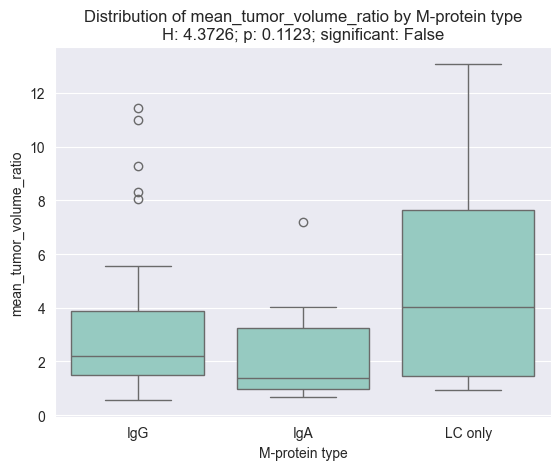

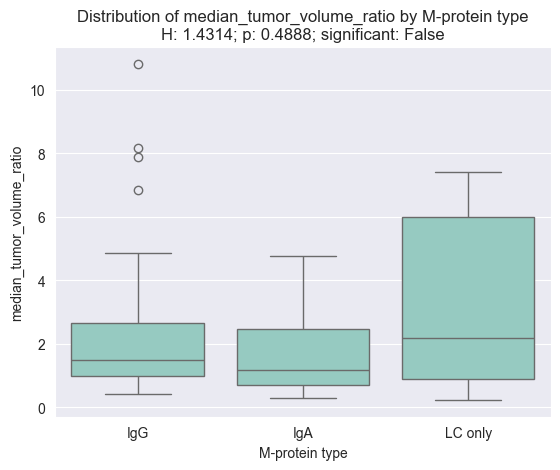

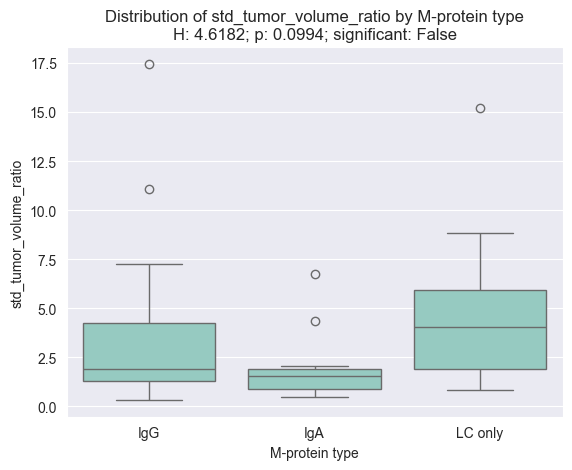

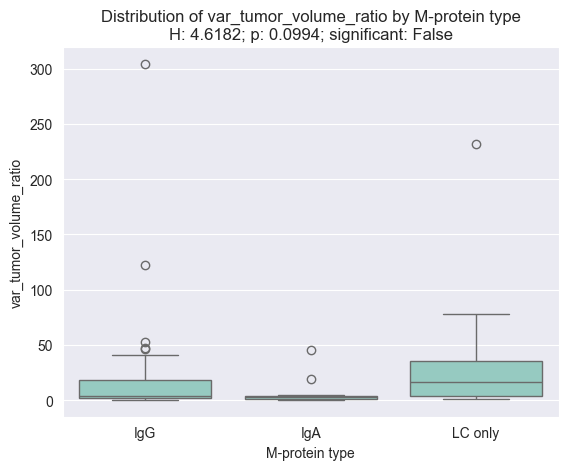

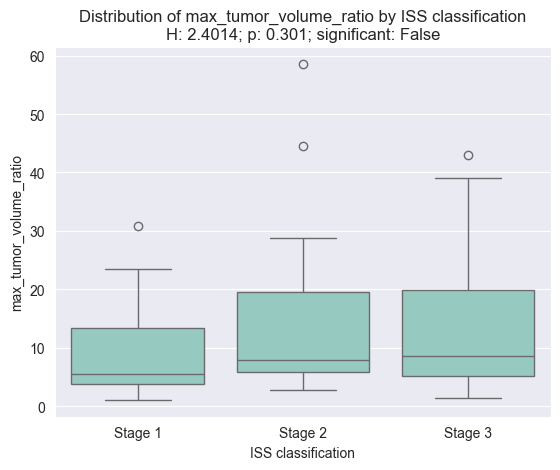

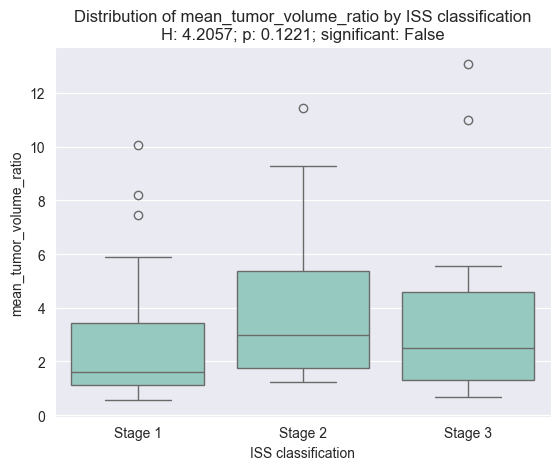

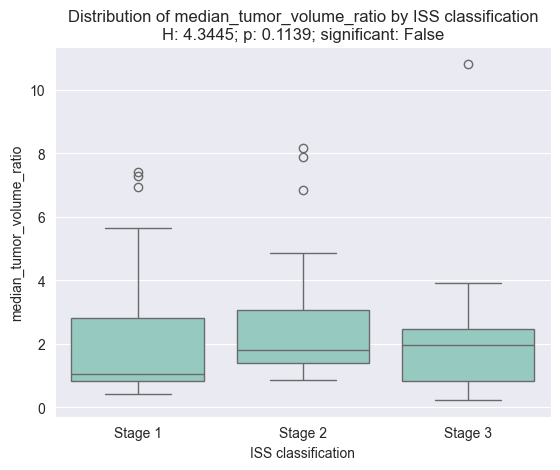

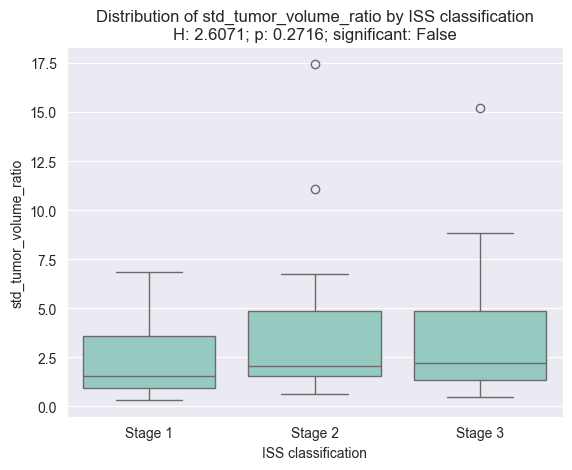

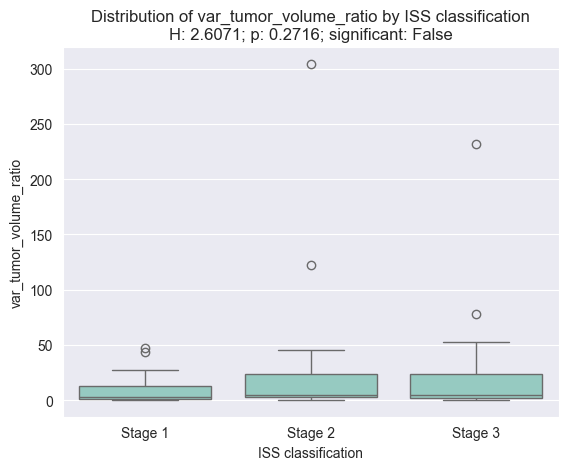

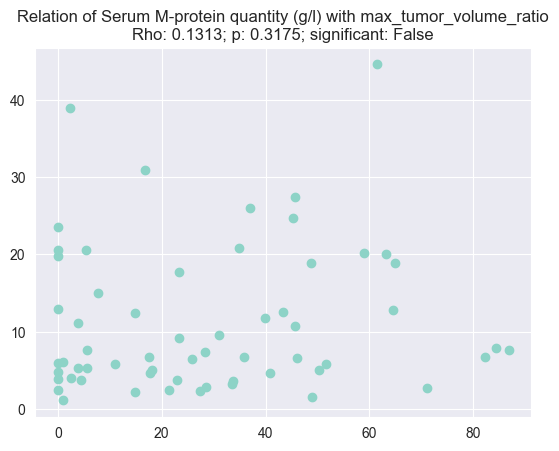

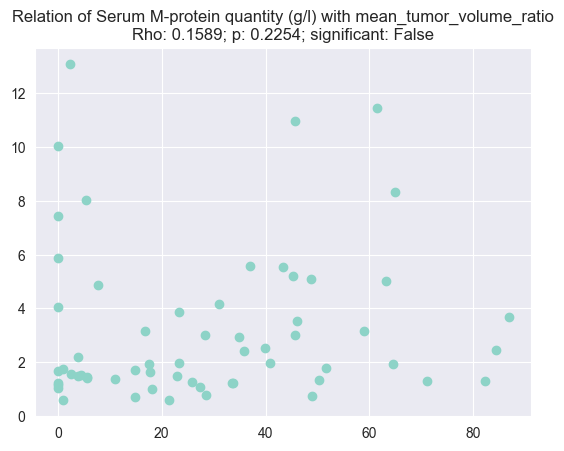

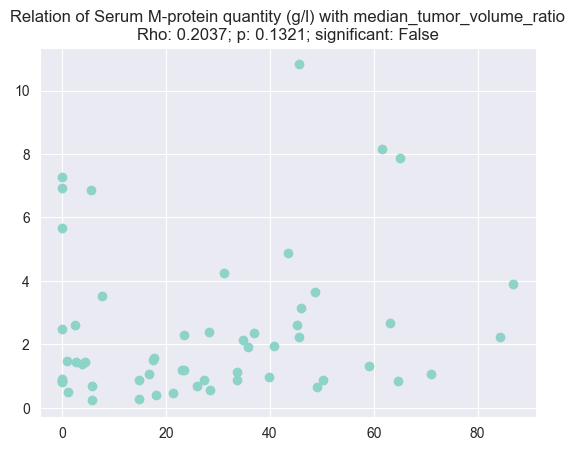

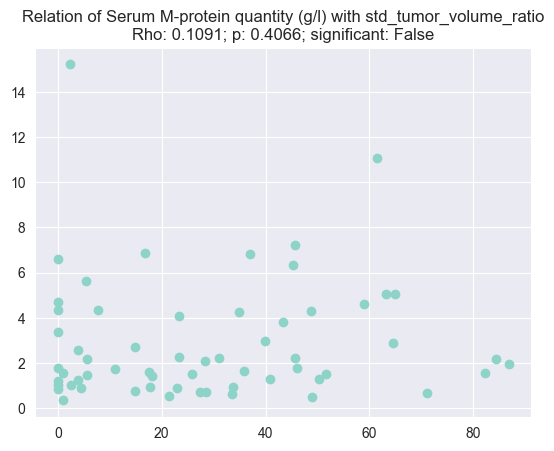

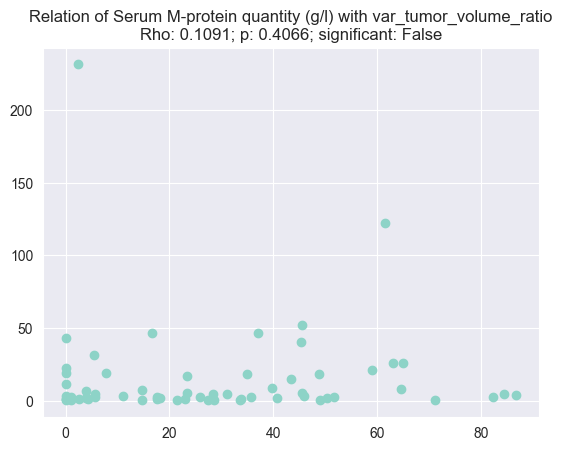

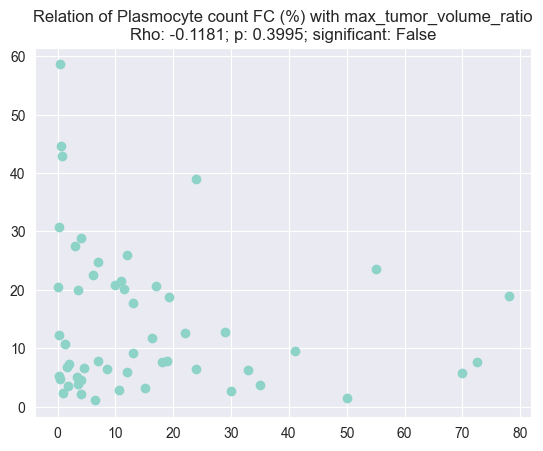

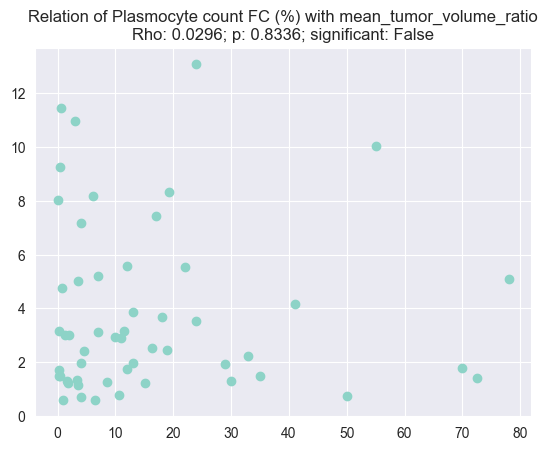

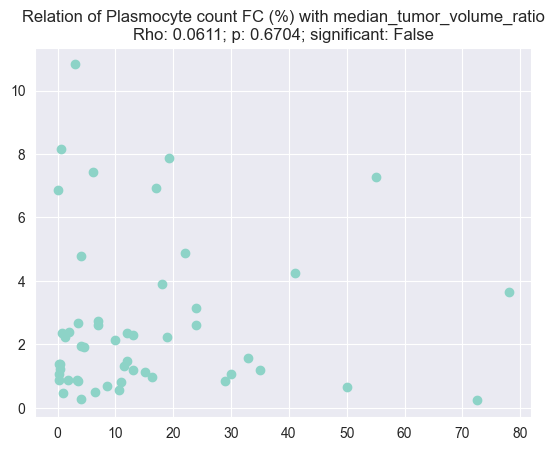

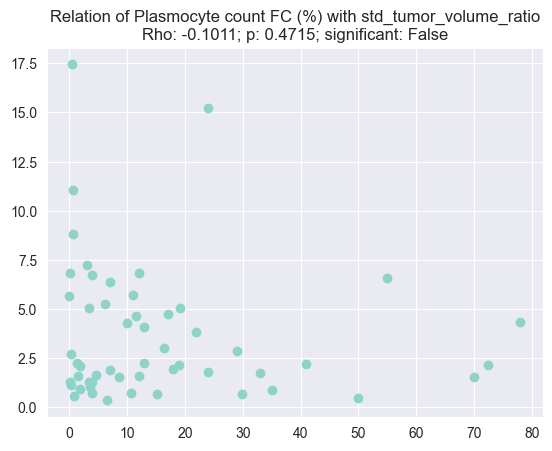

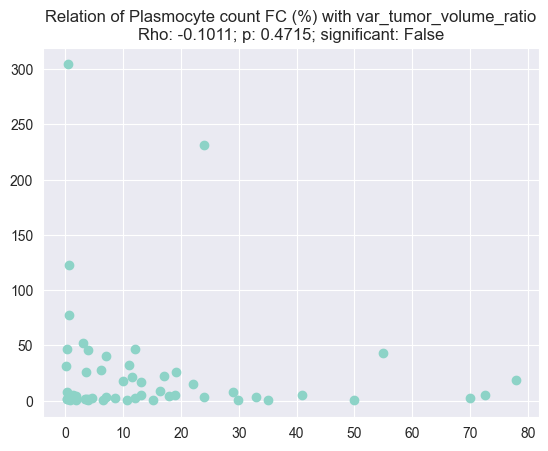

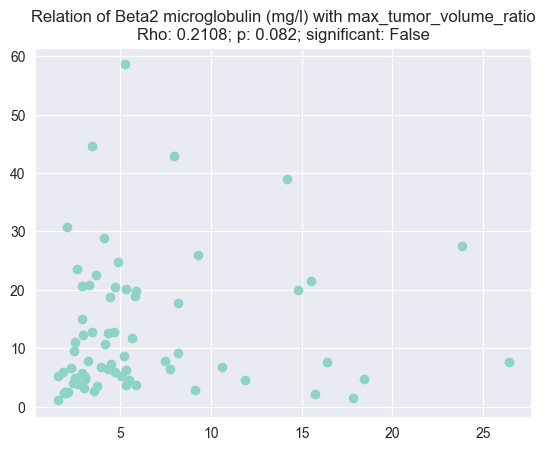

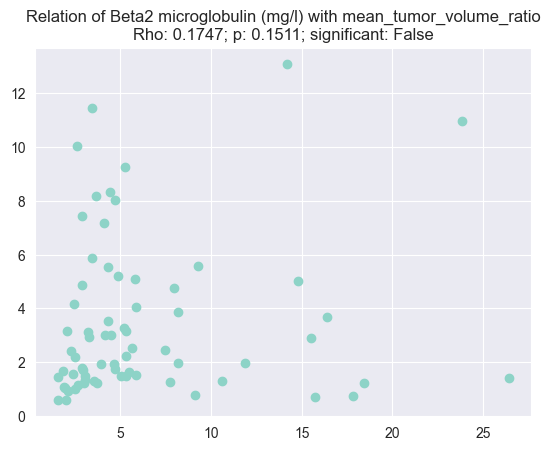

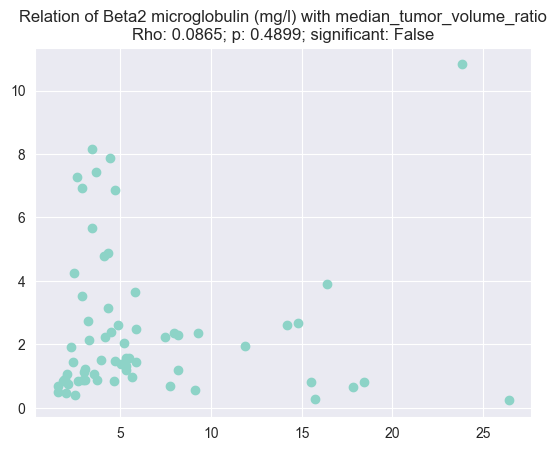

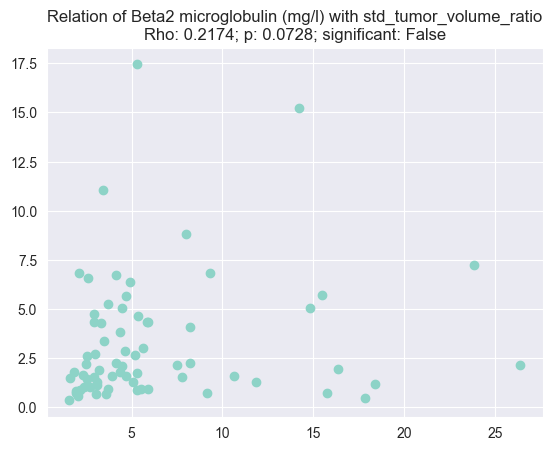

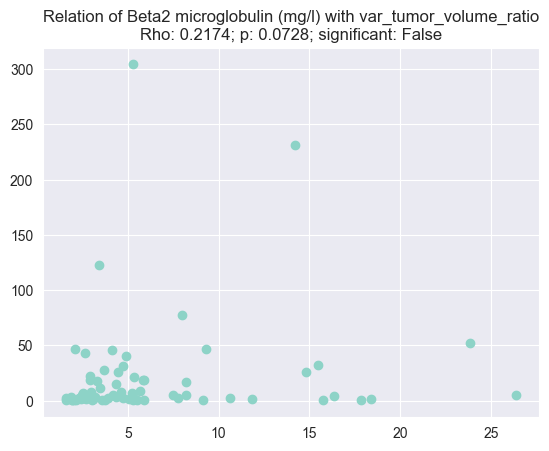

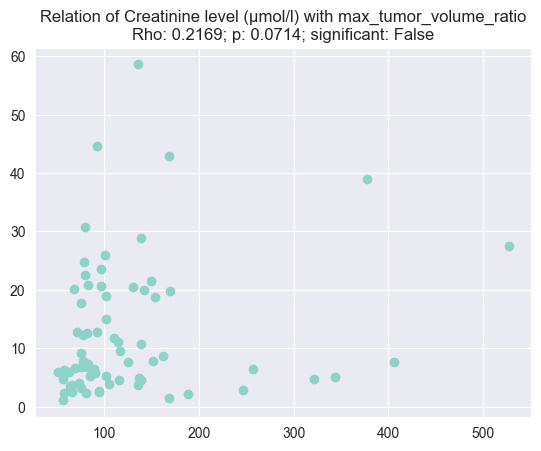

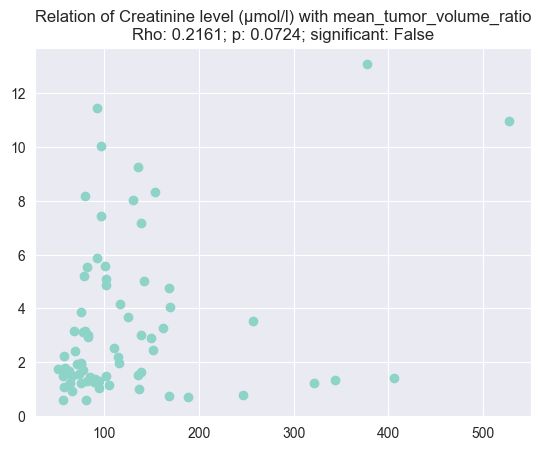

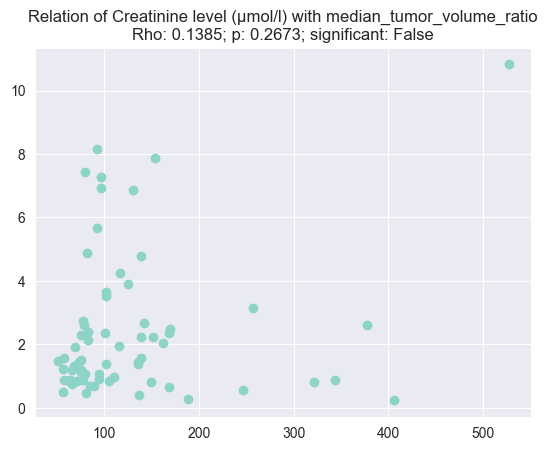

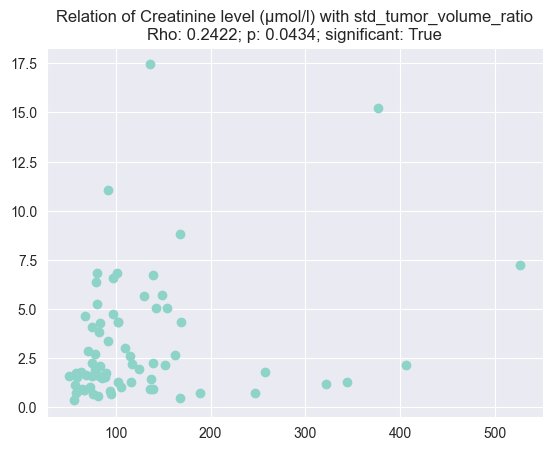

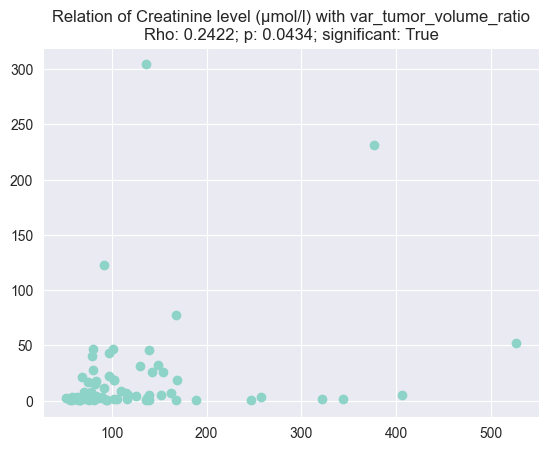

In [4]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal, spearmanr


main_folder = r"E:\DATA_Myelomy"
features = ["vertebra_name", "original_shape_VoxelVolume"]

result = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)

    lesions_path = os.path.join(folder_path, "BMD_radiomics_lesions_features.csv")
    vertebra_path = os.path.join(folder_path, "BMD_radiomics_vertebrae_features.csv")

    df_lesions = pd.read_csv(lesions_path).filter(items=features)
    df_vertebra = pd.read_csv(vertebra_path).filter(items=features)

    df_lesions["lesions_volume"] = df_lesions["original_shape_VoxelVolume"]
    df_vertebra["vertebra_volume"] = df_vertebra["original_shape_VoxelVolume"]

    merged_df = pd.merge(df_lesions, df_vertebra[['vertebra_name', 'vertebra_volume']],
                         left_on='vertebra_name', right_on='vertebra_name').drop("original_shape_VoxelVolume", axis=1)

    merged_df["tumor_volume_ratio"] = merged_df["lesions_volume"] / merged_df["vertebra_volume"] * 100

    temp = {
        "patient": folder_name,
        "max_tumor_volume_ratio": max(merged_df["tumor_volume_ratio"]),
        "mean_tumor_volume_ratio": np.mean(merged_df["tumor_volume_ratio"]),
        "median_tumor_volume_ratio": np.median(merged_df["tumor_volume_ratio"]),
        "std_tumor_volume_ratio": np.std(merged_df["tumor_volume_ratio"]),
        "var_tumor_volume_ratio": np.var(merged_df["tumor_volume_ratio"]),
    }

    result.append(temp)

data = pd.DataFrame(result)

pd.set_option('future.no_silent_downcasting', True)
categorical = ["M-protein type", "ISS classification"]
numeric = ["Serum M-protein quantity (g/l)", "Plasmocyte count FC (%)", "Beta2 microglobulin (mg/l)", "Creatinine level (µmol/l)"]
clinical_features = ["Patient ID"] + categorical + numeric
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
df_final = pd.merge(data, clinical_df[clinical_features], left_on='patient', right_on='Patient ID')

ratio_metrics = [col for col in df_final.columns if "tumor_volume_ratio" in col]


for category in categorical:
    for metric in ratio_metrics:
        groups = [group[metric].dropna().values for name, group in df_final.groupby(category)]

        if len(groups) > 1:
            stat, p = kruskal(*groups)

            sns.set_style("darkgrid")
            sns.boxplot(data=df_final, x=category, y=metric)
            plt.title(f'Distribution of {metric} by {category}\nH: {round(stat, 4)}; p: {round(p, 4)}; significant: {p < 0.05}')
            plt.show()

for num in numeric:
    for metric in ratio_metrics:
        subset = df_final[[num, metric]].dropna()

        if len(subset) > 1:
            rho, p = spearmanr(subset[num], subset[metric])

        plt.scatter(df_final[num], df_final[metric], label=metric)
        plt.title(f'Relation of {num} with {metric}\nRho: {round(rho, 4)}; p: {round(p, 4)}; significant: {p < 0.05}')
        plt.show()